In [ ]:
import csv

files = [
    '/content/drive/MyDrive/Emotion Recognition Project/training_data_2000_20251031_2233.csv',
    '/content/drive/MyDrive/Emotion Recognition Project/tunisian_youtube_comments_unclean.csv',
    '/content/drive/MyDrive/Emotion Recognition Project/twitter_scrapping.csv'
]

merged_rows = []
header = None

for file in files:
    with open(file, newline='', encoding='utf-8') as f:
        reader = csv.reader(f)
        file_header = next(reader)
        if header is None:
            header = file_header
            merged_rows.append(header)
        for row in reader:
            merged_rows.append(row)

# Sauvegarder le fichier fusionné
output_path = '/content/drive/MyDrive/Emotion Recognition Project/merged_data.csv'

with open(output_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerows(merged_rows)

print(f"✅ Fichiers fusionnés avec succès dans {output_path}")



✅ Fichiers fusionnés avec succès dans /content/drive/MyDrive/Emotion Recognition Project/merged_data.csv


In [ ]:
!pip install --quiet pandas matplotlib seaborn scikit-learn imbalanced-learn wordcloud emoji pyspellchecker torch transformers camel-tools stanza simplemma


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 MB 887.5 kB/s eta 0:00:00


In [ ]:
!pip install arabic-reshaper python-bidi wordcloud


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 9.3 MB/s eta 0:00:00


In [ ]:
# Cell 1: Imports
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2
from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud
import emoji
from spellchecker import SpellChecker
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2
from imblearn.over_sampling import SMOTE
import stanza
import emoji
import torch
import arabic_reshaper
from bidi.algorithm import get_display
# Alternative NLP tools
import stanza  # NLP from Stanford with Arabic support
import simplemma  # For Arabic lemmatization (lightweight)

from transformers import AutoTokenizer, AutoModel
import torch
import random

# Initialize Stanza Arabic pipeline (for NER, POS tagging, etc.)
import stanza
stanza.download('ar')
nlp = stanza.Pipeline(lang='ar', processors='tokenize,mwt,pos,lemma,ner')

spell = SpellChecker(language='ar')

arabic_stopwords = set([
    'في', 'من', 'على', 'و', 'ما', 'لا', 'إلى', 'عن', 'أن', 'إن', 'كان', 'مع',
    'هذا', 'هو', 'هي', 'كل', 'لم', 'لكن'
])

tokenizer_arabic = AutoTokenizer.from_pretrained("aubmindlab/bert-base-arabertv2")
model_arabert = AutoModel.from_pretrained("aubmindlab/bert-base-arabertv2")

INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Downloading default packages for language: ar (Arabic) ...
INFO:stanza:File exists: /root/stanza_resources/ar/default.zip
INFO:stanza:Finished downloading models and saved to /root/stanza_resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Loading these models for language: ar (Arabic):
| Processor | Package       |
-----------------------------
| tokenize  | padt          |
| mwt       | padt          |
| pos       | padt_charlm   |
| lemma     | padt_nocharlm |
| ner       | aqmar_charlm  |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: ner
INFO:stanza:Done loading processors!


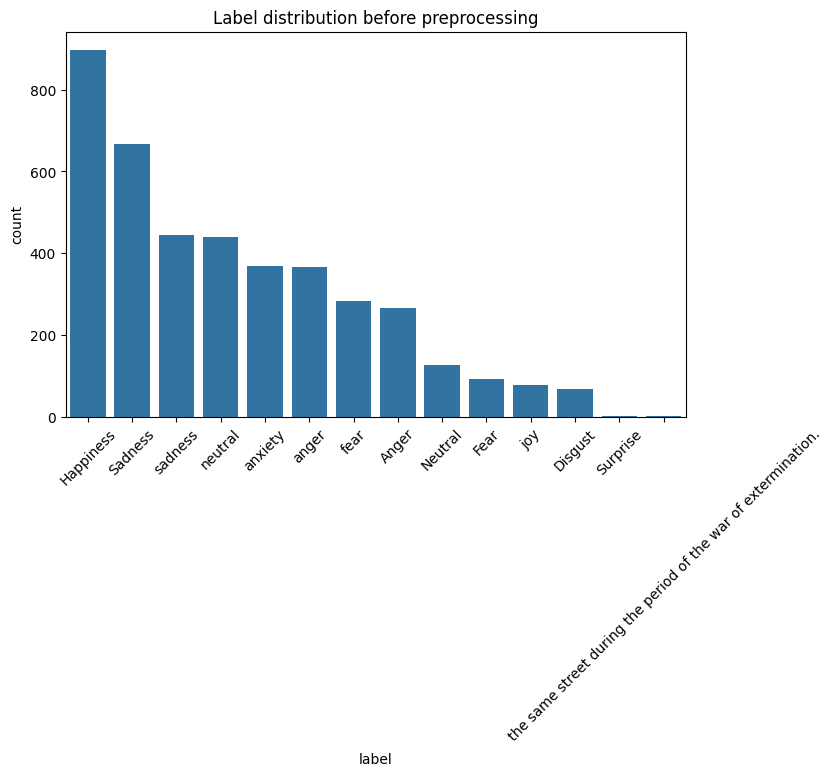

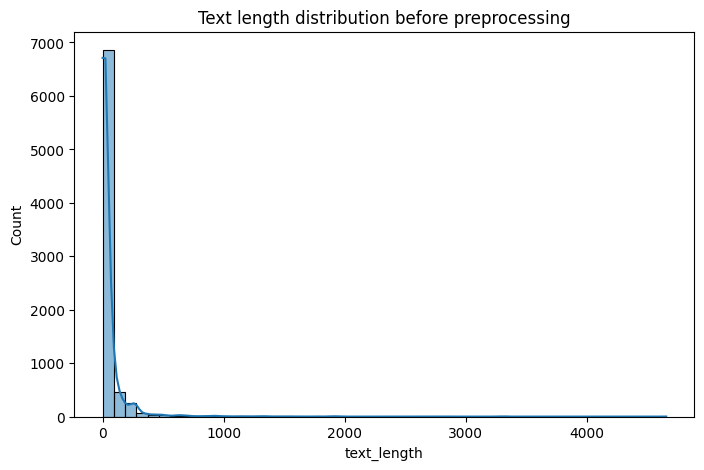

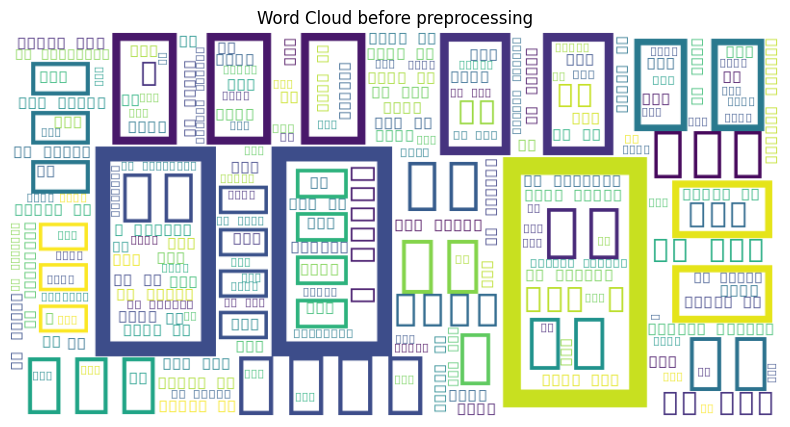

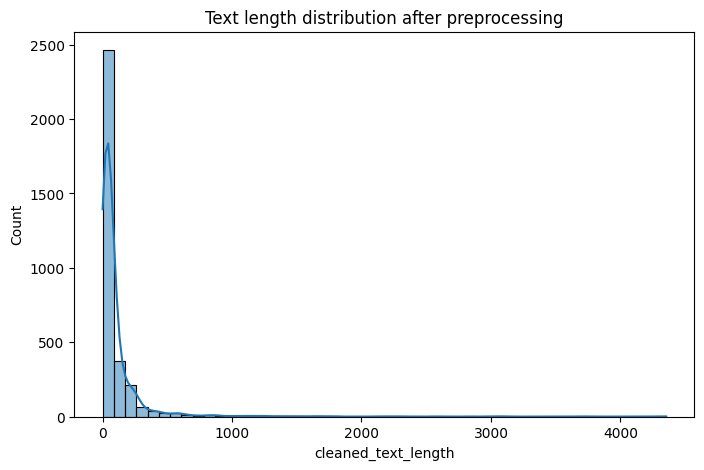

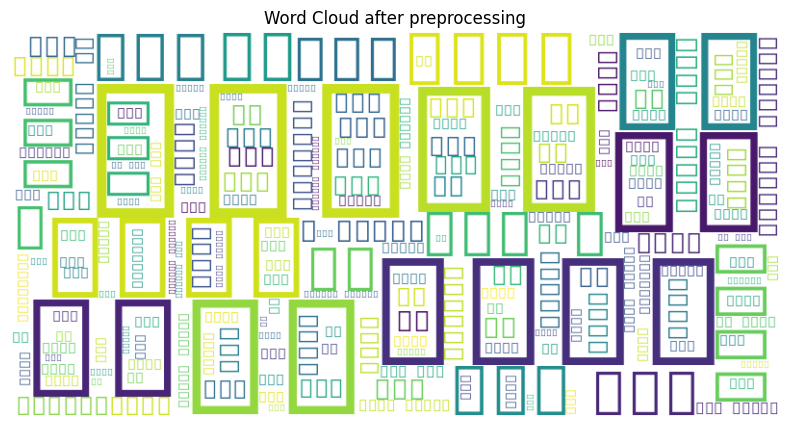

ValueError: could not convert string to float: 'جرائم الدعم السريع العاشرة تنسوا اخوانك السودان'

In [ ]:
# ============================================
# 0️⃣ Emoji sentiment dictionary et pattern
# ============================================
emoji_sentiment_dict = {
    '😀': 'سعيد فرحان', '😂': 'مسرور ضاحك', '😍': 'متحمس سعيد', '😢': 'حزين مغموم',
    '😠': 'غاضب', '😡': 'غضب شديد', '😨': 'خائف قلق', '😰': 'مرهق', '😷': 'مريض',
    '🤢': 'مقرف', '😐': 'محايد', '😴': 'مرهق نعسان', '🤔': 'متفكر', '😞': 'حزين مكتئب'
}
emoji_pattern = re.compile('(' + '|'.join(re.escape(emo) for emo in emoji_sentiment_dict.keys()) + ')')

# ============================================
# 1️⃣ Fonctions utilitaires
# ============================================
def replace_emojis_with_sentiments(text, emoji_dict=emoji_sentiment_dict):
    text = str(text)
    def replacer(match):
        emo = match.group(0)
        sentiments = emoji_dict.get(emo, '')
        return ' ' + sentiments + ' ' if sentiments else ' '
    return emoji_pattern.sub(replacer, text)

def preprocess_arabic_text(text):
    text = replace_emojis_with_sentiments(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens = [spell.correction(t) or t for t in tokens]  # correction orthographique
    tokens = [t for t in tokens if t not in arabic_stopwords]

    try:
        import simplemma
        lemmas = [simplemma.lemmatize(t)[0] if simplemma.lemmatize(t) else t for t in tokens]
    except:
        lemmas = tokens

    return ' '.join(lemmas)


def extract_ner(text):
    doc = nlp(text)
    entities = [ent.text for sent in doc.sentences for ent in sent.ents]
    return entities

def extract_pos(text):
    doc = nlp(text)
    pos_tags = [word.upos for sent in doc.sentences for word in sent.words]
    return pos_tags

def clean_text_for_wordcloud(text):
    # garder seulement caractères arabes + chiffres + espace
    text = re.sub(r'[^\u0600-\u06FF0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ============================================
# 2️⃣ Chargement dataset
# ============================================
df = pd.read_csv('/content/drive/MyDrive/Emotion Recognition Project/merged_data.csv',
                 on_bad_lines='skip', encoding='utf-8')
df['content'] = df['content'].fillna('').astype(str)

# ============================================
# 3️⃣ Visualisation avant preprocessing
# ============================================
plt.figure(figsize=(8,5))
sns.countplot(x='label', data=df, order=df['label'].value_counts().index)
plt.title("Label distribution before preprocessing")
plt.xticks(rotation=45)
plt.show()

df['text_length'] = df['content'].apply(len)
plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title("Text length distribution before preprocessing")
plt.show()

# WordCloud initial
text_wc = clean_text_for_wordcloud(' '.join(df['content']))
reshaped_text = arabic_reshaper.reshape(text_wc)
bidi_text = get_display(reshaped_text)

wordcloud_init = WordCloud(background_color='white', width=800, height=400).generate(bidi_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_init, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud before preprocessing")
plt.show()

# ============================================
# 4️⃣ Prétraitement texte
# ============================================
df = df.drop_duplicates(subset='content', keep='first')
df['cleaned_content'] = df['content'].apply(preprocess_arabic_text)
df['cleaned_content'] = df['cleaned_content'].fillna('').astype(str)
df['entities'] = df['cleaned_content'].apply(extract_ner)
df['pos_tags'] = df['cleaned_content'].apply(extract_pos)

# ============================================
# 5️⃣ Visualisation après preprocessing
# ============================================
df['cleaned_text_length'] = df['cleaned_content'].apply(len)
plt.figure(figsize=(8,5))
sns.histplot(df['cleaned_text_length'], bins=50, kde=True)
plt.title("Text length distribution after preprocessing")
plt.show()

text_wc_clean = clean_text_for_wordcloud(' '.join(df['cleaned_content']))
reshaped_text_clean = arabic_reshaper.reshape(text_wc_clean)
bidi_text_clean = get_display(reshaped_text_clean)

wordcloud_clean = WordCloud(background_color='white', width=800, height=400).generate(bidi_text_clean)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_clean, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud after preprocessing")
plt.show()

# ============================================
# 6️⃣ Encodage labels et split
# ============================================
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

X = df['cleaned_content'].values
y = df['label_encoded'].values

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X.reshape(-1,1), y)
X_resampled = X_resampled.ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# ============================================
# 7️⃣ TF-IDF Vectorization
# ============================================
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# ============================================
# 8️⃣ PCA et Feature Selection
# ============================================
pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_tfidf.toarray())
X_test_pca = pca.transform(X_test_tfidf.toarray())

selector = SelectKBest(chi2, k=1000)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

# ============================================
# 9️⃣ Sauvegarde datasets finaux
# ============================================
final_train_df = pd.DataFrame(X_train_selected.toarray(),
                              columns=[f'feature_{i}' for i in range(X_train_selected.shape[1])])
final_train_df['label'] = y_train

final_test_df = pd.DataFrame(X_test_selected.toarray(),
                             columns=[f'feature_{i}' for i in range(X_test_selected.shape[1])])
final_test_df['label'] = y_test

df.to_csv('preprocessed_sentiment_data_arabic.csv', index=False)
final_train_df.to_csv('final_train_features_arabic.csv', index=False)
final_test_df.to_csv('final_test_features_arabic.csv', index=False)

# ============================================
# 🔟 Description finale du dataset
# ============================================
print("=== Dataset général ===")
print(df.describe(include='all'))

print("\n=== Distribution des labels ===")
print(df['label'].value_counts())

print("\n=== Distribution des labels encodés ===")
print(df['label_encoded'].value_counts())

print("\n✅ Preprocessed and feature datasets saved successfully!")
